# SynthMatch — 01: parameter space, synth, preprocessing, and features

SynthMatch learns to invert a small synthesizer: given the sound of a single note, predict the knob settings that reproduce it. This notebook walks through the first four maps of that pipeline, one stage at a time, with a plot or audio player after every transformation.

We will later train a model on **features**, not raw audio. Everything here exists so that the data, the synth, and the feature extractor stay consistent with each other.

## 0 — Setup

This section loads libraries, pins every numeric constant in one place, and defines two display helpers used throughout the notebook. Nothing is synthesized or loaded from disk yet.

A 2-second clip at our working sample rate has a fixed length:

$$
N = f_s \, T_{\mathrm{clip}} = 22050 \times 2.0 = 44100
$$

With a Hann STFT, `center=True`, `n_fft = 1024`, and `hop = 256`, that clip produces

$$
n_{\mathrm{frames}} = 1 + \frac{N}{\mathrm{hop}} = 1 + \frac{44100}{256} = 173
$$

frequency bins $n_{\mathrm{fft}}/2 + 1 = 513$, and later $n_{\mathrm{mels}} = 128$ mel bands. Those shapes are asserted in later sections; they are defined here so they are not repeated as magic numbers.

In [22]:
from __future__ import annotations

import json
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display
from matplotlib.axes import Axes
from scipy import signal

In [23]:
# --- all numeric constants live here; later cells must not introduce new ones ---
SAMPLE_RATE = 22050
MIDI_NOTE = 48
NOTE_HOLD_S = 1.0
CLIP_LEN_S = 2.0
N_FFT = 1024
HOP = 256
N_MELS = 128
FMIN = 0.0
FMAX = SAMPLE_RATE / 2.0
EPS = 1e-6
TOP_DB = 40
PEAK_TARGET = 0.9
SILENCE_RMS_THRESHOLD = 1e-3
SEED = 1234
N_LABEL_DRAWS = 4000

N_SAMPLES = int(CLIP_LEN_S * SAMPLE_RATE)       # 44100
N_HOLD = int(NOTE_HOLD_S * SAMPLE_RATE)         # 22050
N_FREQ_BINS = N_FFT // 2 + 1                    # 513
N_FRAMES = 1 + N_SAMPLES // HOP                 # 173 with center=True

assert N_SAMPLES == 44100
assert N_HOLD == 22050
assert N_FREQ_BINS == 513
assert N_FRAMES == 173

RNG = np.random.default_rng(SEED)

ROOT = Path.cwd()
if not (ROOT / "spec" / "params.json").exists():
    ROOT = ROOT.parent
SPEC_PATH = ROOT / "spec" / "params.json"
TEST_AUDIO_DIR = ROOT / "test_audio"

print(f"sample rate     : {SAMPLE_RATE} Hz")
print(f"clip            : {CLIP_LEN_S} s  →  {N_SAMPLES} samples")
print(f"note hold       : {NOTE_HOLD_S} s  →  {N_HOLD} samples")
print(f"STFT            : n_fft={N_FFT}, hop={HOP}  →  ({N_FREQ_BINS}, {N_FRAMES})")
print(f"mel             : n_mels={N_MELS}, fmin={FMIN}, fmax={FMAX}")
print(f"spec path       : {SPEC_PATH}  exists={SPEC_PATH.exists()}")
print(f"test_audio dir  : {TEST_AUDIO_DIR}  exists={TEST_AUDIO_DIR.exists()}")

sample rate     : 22050 Hz
clip            : 2.0 s  →  44100 samples
note hold       : 1.0 s  →  22050 samples
STFT            : n_fft=1024, hop=256  →  (513, 173)
mel             : n_mels=128, fmin=0.0, fmax=11025.0
spec path       : /Users/prestondavis/Desktop/GenSynth/spec/params.json  exists=True
test_audio dir  : /Users/prestondavis/Desktop/GenSynth/test_audio  exists=True


In [24]:
%matplotlib inline

plt.rcParams.update(
    {
        "figure.figsize": (10, 3.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.grid.which": "major",
        "grid.alpha": 0.35,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

In [25]:
def show_audio(x: np.ndarray, label: str = "", sr: int = SAMPLE_RATE) -> None:
    """Play a signal in the notebook, preserving its actual amplitude."""
    x = np.asarray(x, dtype=np.float32)
    play = x.T if x.ndim == 2 else np.reshape(x, -1)
    if label:
        print(label)
    display(Audio(play, rate=sr, normalize=False))


def stats_table(
    named: dict[str, np.ndarray],
    sr: int | dict[str, int] = SAMPLE_RATE,
) -> pd.DataFrame:
    """Print shape, dtype, min, max, peak, RMS, and duration for named signals."""
    rows: list[dict[str, object]] = []
    for name, x in named.items():
        x = np.asarray(x)
        sr_i = int(sr[name]) if isinstance(sr, dict) else int(sr)
        n_time = int(x.shape[0]) if x.ndim >= 1 else 0
        if x.size == 0:
            peak = rms = lo = hi = 0.0
        else:
            xf = x.astype(np.float64, copy=False).reshape(-1)
            lo = float(xf.min())
            hi = float(xf.max())
            peak = float(np.max(np.abs(xf)))
            rms = float(np.sqrt(np.mean(xf * xf)))
        rows.append(
            {
                "name": name,
                "shape": tuple(x.shape),
                "dtype": str(x.dtype),
                "sr": sr_i,
                "min": lo,
                "max": hi,
                "peak": peak,
                "rms": rms,
                "duration_s": n_time / sr_i if sr_i else 0.0,
            }
        )
    df = pd.DataFrame(rows)
    display(df)
    return df

In [26]:
# smoke-check the helpers on a short click (not part of the pipeline)
_demo = np.zeros(N_SAMPLES, dtype=np.float32)
_demo[0] = PEAK_TARGET
stats_table({"click": _demo})
show_audio(_demo, label="setup smoke-check: a single-sample click at PEAK_TARGET")

,name,shape,dtype,sr,min,max,peak,rms,duration_s
0,click,"(44100,)",float32,22050,0.0,0.9,0.9,0.004286,2.0


setup smoke-check: a single-sample click at PEAK_TARGET


**Output of this step.** Config and helpers are in memory. Derived shapes that later sections will assert:

| quantity | value |
|---|---|
| audio clip $x$ | `(44100,)` float32 |
| STFT magnitude | `(513, 173)` |
| mel filterbank | `(128, 513)` |
| log-mel / features | `(128, 173)` then `(1, 128, 173)` |

`SPEC_PATH` and `TEST_AUDIO_DIR` point at `spec/params.json` and `test_audio/` relative to the project root. The next section (parameter space) will load the spec.

## 1 — Data ingestion and preprocessing

A recording on disk is not yet a training example. Different files can have different sample rates, channel counts, loudness, and leading silence. Before any model sees audio, we force every clip into the same **canonical** form: one channel, \(f_s = 22050\) Hz, length \(T_{\mathrm{clip}} = 2\) s, peak near `PEAK_TARGET`.

The steps, in order:

1. **Mono.** Average the channels (soundfile layout is samples \(\times\) channels):
   $$x_{\mathrm{mono}}[n] = \frac{1}{C}\sum_{c=1}^{C} x[n,c]$$
2. **Resample** to `SAMPLE_RATE` with librosa.
3. **Trim** leading and trailing silence with `librosa.effects.trim` (`top_db=TOP_DB`).
4. **Pad or crop** to exactly \(N = f_s\,T_{\mathrm{clip}} = 44100\) samples (crop from the start; pad zeros on the right).
5. **Peak-normalize** unless the clip is near silence:
   $$
   x \leftarrow x\cdot\frac{A_{\mathrm{peak}}}{\max_n |x[n]|}
   \quad\text{if}\quad
   \mathrm{RMS}(x) \ge \varepsilon
   $$

`test_audio/` is optional. If it has no WAV files, this section prints a message and uses a **fallback** stereo sine (off-rate, with leading/trailing silence) so every stage is still visible. After Section 3, that fallback can be replaced by the toy synth.

The notebook must still **Restart & Run All** cleanly with an empty `test_audio/` folder.

In [27]:
def load_audio(path: str | Path) -> tuple[np.ndarray, int]:
    """Load a WAV via soundfile, keeping original channels and sample rate."""
    audio, sr = sf.read(path, always_2d=False)
    return np.asarray(audio), int(sr)


def to_mono(audio: np.ndarray) -> np.ndarray:
    """Average channels to a 1-D float64 signal."""
    audio = np.asarray(audio)
    if audio.ndim == 1:
        return audio.astype(np.float64, copy=False)
    return np.mean(audio, axis=1, dtype=np.float64)


def pad_or_crop(x: np.ndarray, n: int = N_SAMPLES) -> np.ndarray:
    """Right-pad with zeros or crop from the start to exactly n samples."""
    x = np.asarray(x)
    if x.shape[0] >= n:
        return x[:n]
    return np.pad(x, (0, n - x.shape[0]))


def peak_normalize(x: np.ndarray) -> np.ndarray:
    """Scale peak to PEAK_TARGET unless RMS is below SILENCE_RMS_THRESHOLD."""
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return x.astype(np.float32)
    rms = float(np.sqrt(np.mean(x * x)))
    if rms < SILENCE_RMS_THRESHOLD:
        return x.astype(np.float32)
    peak = float(np.max(np.abs(x)))
    if peak == 0.0:
        return x.astype(np.float32)
    return (x * (PEAK_TARGET / peak)).astype(np.float32)


def preprocess_with_report(
    audio: np.ndarray, sr: int
) -> tuple[np.ndarray, dict[str, object]]:
    """Preprocess audio and return the clip plus intermediates for plotting."""
    raw = np.asarray(audio)
    mono = to_mono(raw)
    resampled = np.asarray(
        librosa.resample(mono, orig_sr=sr, target_sr=SAMPLE_RATE),
        dtype=np.float64,
    )
    trimmed, (trim_start, trim_end) = librosa.effects.trim(
        resampled, top_db=TOP_DB
    )
    trimmed = np.asarray(trimmed, dtype=np.float64)
    padded = pad_or_crop(trimmed, N_SAMPLES)
    normalized = peak_normalize(padded)
    assert normalized.shape == (N_SAMPLES,), normalized.shape
    assert normalized.dtype == np.float32, normalized.dtype
    report: dict[str, object] = {
        "raw": raw,
        "mono": mono,
        "resampled": resampled,
        "trimmed": trimmed,
        "padded": padded,
        "normalized": normalized,
        "trim_start": int(trim_start),
        "trim_end": int(trim_end),
        "sr_in": int(sr),
    }
    return normalized, report


def preprocess(audio: np.ndarray, sr: int) -> np.ndarray:
    """Mono, resample, trim, pad/crop, and peak-normalize to a fixed-length clip."""
    y, _ = preprocess_with_report(audio, sr)
    return y


def list_wavs(folder: Path) -> list[Path]:
    """Return WAV paths in folder, sorted by name."""
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".wav"
    )


def make_fallback_clip() -> tuple[np.ndarray, int]:
    """Stereo sine with lead/trail silence at 2× SAMPLE_RATE (empty-folder demo)."""
    sr = SAMPLE_RATE * 2
    lead_n = int(((CLIP_LEN_S - NOTE_HOLD_S) / 2.0) * sr)
    tone_n = int(NOTE_HOLD_S * sr)
    trail_n = int(CLIP_LEN_S * sr)
    f0 = 440.0 * (2.0 ** ((MIDI_NOTE - 69) / 12.0))
    t = np.arange(tone_n, dtype=np.float64) / sr
    tone = (PEAK_TARGET / 2.0) * np.sin(2.0 * np.pi * f0 * t)
    mono = np.concatenate([np.zeros(lead_n), tone, np.zeros(trail_n)])
    stereo = np.column_stack([mono, mono]).astype(np.float32)
    return stereo, sr


def plot_waveform(
    ax: Axes,
    x: np.ndarray,
    sr: int,
    title: str,
    vlines_s: tuple[float, float] | None = None,
) -> None:
    """Plot a 1-D waveform against time in seconds."""
    x = np.asarray(x)
    if x.ndim == 2:
        x = np.mean(x, axis=1)
    n = int(x.shape[0])
    t = np.arange(n, dtype=np.float64) / sr if n else np.zeros(0)
    ax.plot(t, x, lw=0.8, color="0.15")
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("amplitude")
    if vlines_s is not None:
        ax.axvline(vlines_s[0], color="C1", ls="--", lw=1.2, label="trim start")
        ax.axvline(vlines_s[1], color="C3", ls="--", lw=1.2, label="trim end")
        ax.legend(loc="upper right")
    if n:
        ax.set_xlim(float(t[0]), float(t[-1]))

In [28]:
wav_paths = list_wavs(TEST_AUDIO_DIR)
ingest_rows: list[dict[str, object]] = []
loaded: dict[str, tuple[np.ndarray, int]] = {}

if wav_paths:
    print(f"found {len(wav_paths)} WAV file(s) in {TEST_AUDIO_DIR}")
    for path in wav_paths:
        audio, sr = load_audio(path)
        loaded[path.name] = (audio, sr)
        n_time = int(audio.shape[0])
        n_ch = 1 if audio.ndim == 1 else int(audio.shape[1])
        xf = audio.astype(np.float64, copy=False).reshape(-1)
        ingest_rows.append(
            {
                "filename": path.name,
                "sample_rate": sr,
                "channels": n_ch,
                "duration_s": n_time / sr,
                "peak": float(np.max(np.abs(xf))) if xf.size else 0.0,
                "rms": float(np.sqrt(np.mean(xf * xf))) if xf.size else 0.0,
            }
        )
    selected_name = wav_paths[0].name
    raw_audio, raw_sr = loaded[selected_name]
    selected_label = selected_name
else:
    print(
        f"No WAV files in {TEST_AUDIO_DIR}/. "
        "Using a fallback stereo sine (off-rate, with silence padding) "
        "so preprocessing can still be demonstrated. "
        "Drop WAVs into that folder to ingest real recordings. "
        "After Section 3 this fallback can come from the toy synth."
    )
    raw_audio, raw_sr = make_fallback_clip()
    selected_name = "(fallback sine)"
    selected_label = selected_name
    xf = raw_audio.astype(np.float64).reshape(-1)
    ingest_rows.append(
        {
            "filename": selected_name,
            "sample_rate": raw_sr,
            "channels": 1 if raw_audio.ndim == 1 else int(raw_audio.shape[1]),
            "duration_s": raw_audio.shape[0] / raw_sr,
            "peak": float(np.max(np.abs(xf))),
            "rms": float(np.sqrt(np.mean(xf * xf))),
        }
    )

ingest_df = pd.DataFrame(ingest_rows)
display(ingest_df)
print(f"selected for plots: {selected_label}")

No WAV files in /Users/prestondavis/Desktop/GenSynth/test_audio/. Using a fallback stereo sine (off-rate, with silence padding) so preprocessing can still be demonstrated. Drop WAVs into that folder to ingest real recordings. After Section 3 this fallback can come from the toy synth.


,filename,sample_rate,channels,duration_s,peak,rms
0,(fallback sine),44100,2,3.5,0.45,0.170119


selected for plots: (fallback sine)


raw shape         : (154350, 2)  sr=44100
mono shape        : (154350,)
resampled shape   : (77175,)  sr=22050
trimmed shape     : (24064,)
padded shape      : (44100,)
normalized shape  : (44100,)  dtype=float32
trim indices      : [10240, 34304)  →  0.464–1.556 s


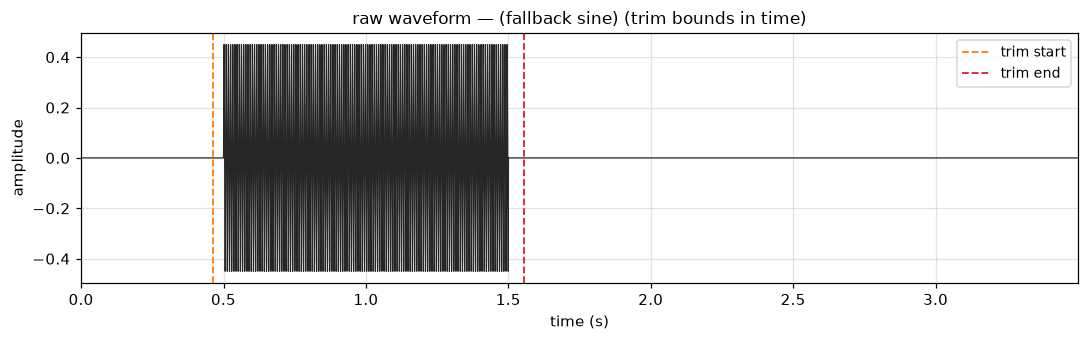

In [29]:
y, report = preprocess_with_report(raw_audio, raw_sr)
trim_start = int(report["trim_start"])
trim_end = int(report["trim_end"])
trim_start_s = trim_start / SAMPLE_RATE
trim_end_s = trim_end / SAMPLE_RATE

print(f"raw shape         : {np.asarray(report['raw']).shape}  sr={raw_sr}")
print(f"mono shape        : {np.asarray(report['mono']).shape}")
print(f"resampled shape   : {np.asarray(report['resampled']).shape}  sr={SAMPLE_RATE}")
print(f"trimmed shape     : {np.asarray(report['trimmed']).shape}")
print(f"padded shape      : {np.asarray(report['padded']).shape}")
print(f"normalized shape  : {y.shape}  dtype={y.dtype}")
print(f"trim indices      : [{trim_start}, {trim_end})  →  {trim_start_s:.3f}–{trim_end_s:.3f} s")

assert y.shape == (N_SAMPLES,)
assert y.dtype == np.float32

fig, ax = plt.subplots(figsize=(10, 3.2))
plot_waveform(
    ax,
    np.asarray(report["raw"]),
    raw_sr,
    f"raw waveform — {selected_label} (trim bounds in time)",
    vlines_s=(trim_start_s, trim_end_s),
)
fig.tight_layout()
plt.show()

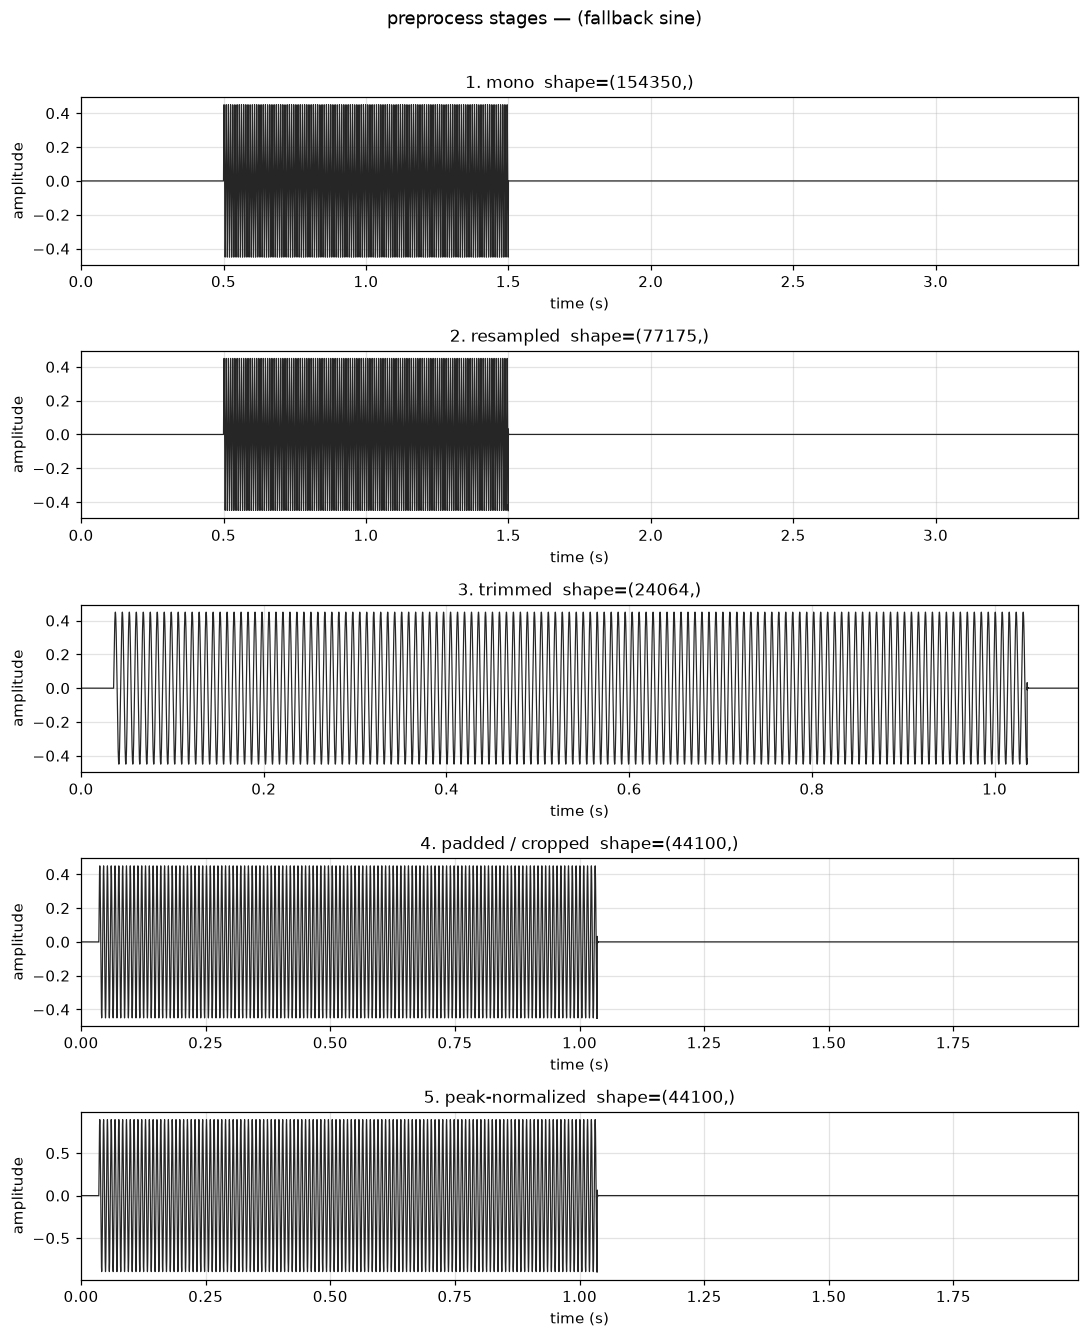

In [30]:
stage_rows = [
    ("1. mono", np.asarray(report["mono"]), int(report["sr_in"])),
    ("2. resampled", np.asarray(report["resampled"]), SAMPLE_RATE),
    ("3. trimmed", np.asarray(report["trimmed"]), SAMPLE_RATE),
    ("4. padded / cropped", np.asarray(report["padded"]), SAMPLE_RATE),
    ("5. peak-normalized", y, SAMPLE_RATE),
]

fig, axes = plt.subplots(
    len(stage_rows), 1, figsize=(10, 12), sharex=False
)
for ax, (title, sig, sr_i) in zip(axes, stage_rows):
    plot_waveform(ax, sig, sr_i, f"{title}  shape={sig.shape}")
fig.suptitle(f"preprocess stages — {selected_label}", y=1.01)
fig.tight_layout()
plt.show()

In [31]:
print("before / after")
stats_table(
    {"raw": np.asarray(report["raw"]), "processed": y},
    sr={"raw": raw_sr, "processed": SAMPLE_RATE},
)

show_audio(np.asarray(report["raw"]), label=f"raw — {selected_label}", sr=raw_sr)
show_audio(y, label=f"processed — {selected_label}", sr=SAMPLE_RATE)

before / after


,name,shape,dtype,sr,min,max,peak,rms,duration_s
0,raw,"(154350, 2)",float32,44100,-0.45,0.450000,0.45,0.170119,3.5
1,processed,"(44100,)",float32,22050,-0.90,0.895193,0.90,0.447687,2.0


raw — (fallback sine)


processed — (fallback sine)


**Output of this step.** `preprocess` returns a mono `float32` vector \(x\in\mathbb{R}^{N}\) with \(N=44100\) (`CLIP_LEN_S * SAMPLE_RATE`). `preprocess_with_report` also returns a dict of intermediates (`raw`, `mono`, `resampled`, `trimmed`, `padded`, `normalized`) plus `trim_start` / `trim_end` on the resampled timeline. The ingest table lists every WAV in `test_audio/` (or the fallback row if that folder is empty).

## 2 — Parameter space

A synth preset is a point in a mixed space: one categorical knob (waveform) and seven continuous knobs. For learning we **do not** predict raw Hertz or seconds. We quantize each continuous knob into `n` classes and predict those class indices. Decoding a class \(k \in \{0,\ldots,n-1\}\) uses a normalized coordinate \(t = k/(n-1)\):

$$
v_{\mathrm{lin}}(k) = v_{\min} + t\,(v_{\max}-v_{\min})
\qquad
v_{\mathrm{log}}(k) = v_{\min}\left(\frac{v_{\max}}{v_{\min}}\right)^{t}
$$

The inverse maps a physical value back to the nearest class (clip to range, then round). Random training labels are drawn **uniformly over classes**, not uniformly over Hertz — that is what makes log-spaced knobs put equal mass on each octave.

In [32]:
def load_spec(path: str | Path) -> list[dict[str, object]]:
    """Load the parameter spec as a list of knob dicts."""
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    return list(data["params"])


def class_to_value(param: dict[str, object], k: int) -> float | str:
    """Map class index k to a physical value or category name."""
    n = int(param["n_classes"])
    k = int(np.clip(k, 0, n - 1))
    if param["type"] == "categorical":
        return str(list(param["choices"])[k])
    t = k / (n - 1) if n > 1 else 0.0
    lo = float(param["min"])
    hi = float(param["max"])
    if param["scale"] == "log":
        return float(lo * (hi / lo) ** t)
    return float(lo + t * (hi - lo))


def value_to_class(param: dict[str, object], v: float | str) -> int:
    """Map a physical value or category name back to the nearest class index."""
    n = int(param["n_classes"])
    if param["type"] == "categorical":
        choices = [str(c) for c in list(param["choices"])]
        if isinstance(v, str):
            return choices.index(v)
        return int(np.clip(int(v), 0, n - 1))
    lo = float(param["min"])
    hi = float(param["max"])
    x = float(np.clip(float(v), lo, hi))
    if param["scale"] == "log":
        t = float(np.log(x / lo) / np.log(hi / lo))
    else:
        t = (x - lo) / (hi - lo) if hi != lo else 0.0
    return int(np.clip(np.rint(t * (n - 1)), 0, n - 1))


def random_labels(
    spec: list[dict[str, object]], rng: np.random.Generator
) -> dict[str, int]:
    """Draw an independent uniform class index for every knob."""
    return {str(p["name"]): int(rng.integers(0, int(p["n_classes"]))) for p in spec}


def labels_to_preset(
    spec: list[dict[str, object]], labels: dict[str, int]
) -> dict[str, float | str]:
    """Decode class labels into physical knob values."""
    return {str(p["name"]): class_to_value(p, labels[str(p["name"])]) for p in spec}


def describe_preset(preset: dict[str, float | str]) -> str:
    """Return a one-line human-readable summary of a preset."""
    by_name = {str(p["name"]): p for p in SPEC}
    parts: list[str] = []
    for name, value in preset.items():
        param = by_name.get(name, {})
        unit = param.get("unit")
        if isinstance(value, str):
            parts.append(f"{name}={value}")
        elif unit == "Hz":
            parts.append(f"{name}={value:.1f} Hz")
        elif unit == "s":
            parts.append(f"{name}={value:.4g} s")
        elif unit == "Q":
            parts.append(f"{name}={value:.3g} Q")
        else:
            parts.append(f"{name}={value:.3f}")
    return ", ".join(parts)

In [33]:
SPEC = load_spec(SPEC_PATH)
CONTINUOUS = [p for p in SPEC if p["type"] == "continuous"]
CATEGORICAL = [p for p in SPEC if p["type"] == "categorical"]

print(f"loaded {len(SPEC)} knobs from {SPEC_PATH}")
for p in SPEC:
    if p["type"] == "categorical":
        print(f"  {p['name']}: categorical {list(p['choices'])}")
    else:
        print(
            f"  {p['name']}: {p['scale']} "
            f"{p['min']}–{p['max']} {p.get('unit', '')} "
            f"({p['n_classes']} classes)"
        )

n_classes_cont = int(CONTINUOUS[0]["n_classes"])
class_value_table = pd.DataFrame(
    {
        f"{p['name']} ({p.get('unit', '')})": [
            class_to_value(p, k) for k in range(n_classes_cont)
        ]
        for p in CONTINUOUS
    },
    index=pd.Index(range(n_classes_cont), name="class"),
)

def _fmt_cell(name_with_unit: str, v: float) -> str:
    if name_with_unit.startswith("cutoff"):
        return f"{v:.1f} Hz"
    if " (s)" in name_with_unit:
        return f"{v:.4g} s"
    if name_with_unit.startswith("resonance"):
        return f"{v:.3g}"
    return f"{v:.3f}"

formatted = class_value_table.copy()
for col in formatted.columns:
    formatted[col] = [_fmt_cell(col, float(v)) for v in class_value_table[col]]

assert class_value_table.shape == (16, 7), class_value_table.shape
print(f"class → value table shape: {class_value_table.shape}")
display(formatted)

loaded 8 knobs from /Users/prestondavis/Desktop/GenSynth/spec/params.json
  waveform: categorical ['sine', 'saw', 'square', 'triangle']
  cutoff: log 100.0–10000.0 Hz (16 classes)
  resonance: log 0.5–10.0 Q (16 classes)
  attack: log 0.001–1.0 s (16 classes)
  decay: log 0.01–1.0 s (16 classes)
  sustain: linear 0.0–1.0 amp (16 classes)
  release: log 0.01–1.0 s (16 classes)
  noise_level: linear 0.0–0.5 amp (16 classes)
class → value table shape: (16, 7)


,cutoff (Hz),resonance (Q),attack (s),decay (s),sustain (amp),release (s),noise_level (amp)
class,,,,,,,
0,100.0 Hz,0.5,0.001 s,0.01 s,0.000,0.01 s,0.000
1,135.9 Hz,0.611,0.001585 s,0.01359 s,0.067,0.01359 s,0.033
2,184.8 Hz,0.745,0.002512 s,0.01848 s,0.133,0.01848 s,0.067
3,251.2 Hz,0.91,0.003981 s,0.02512 s,0.200,0.02512 s,0.100
4,341.5 Hz,1.11,0.00631 s,0.03415 s,0.267,0.03415 s,0.133
5,464.2 Hz,1.36,0.01 s,0.04642 s,0.333,0.04642 s,0.167
6,631.0 Hz,1.66,0.01585 s,0.0631 s,0.400,0.0631 s,0.200
7,857.7 Hz,2.02,0.02512 s,0.08577 s,0.467,0.08577 s,0.233
8,1165.9 Hz,2.47,0.03981 s,0.1166 s,0.533,0.1166 s,0.267


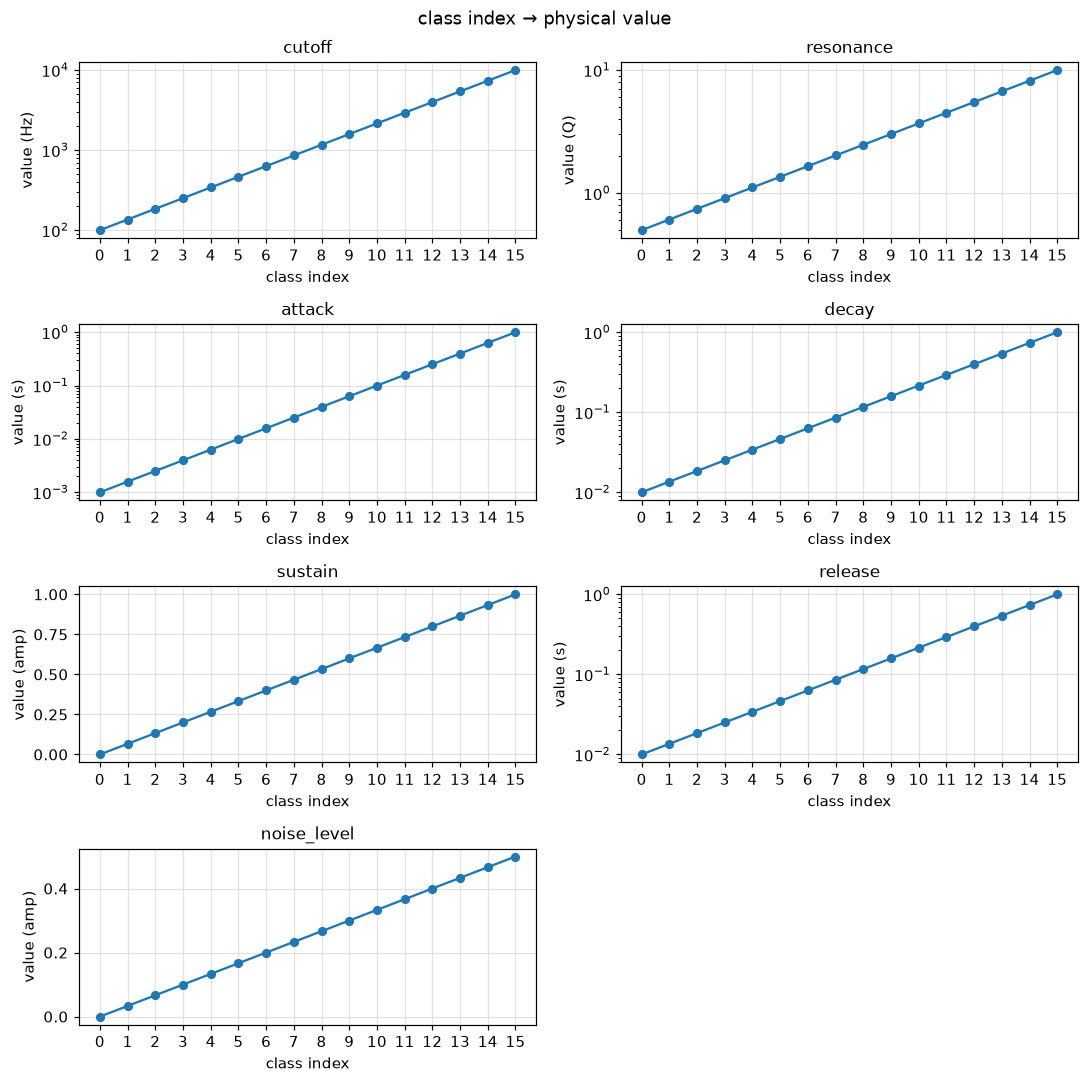

In [34]:
n_cont = len(CONTINUOUS)
n_cols = 2
n_rows = int(np.ceil(n_cont / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10), squeeze=False)
for i, param in enumerate(CONTINUOUS):
    ax = axes[i // n_cols][i % n_cols]
    n = int(param["n_classes"])
    ks = np.arange(n)
    vs = np.array([class_to_value(param, int(k)) for k in ks], dtype=np.float64)
    ax.plot(ks, vs, "o-", color="C0", ms=5)
    ax.set_title(str(param["name"]))
    ax.set_xlabel("class index")
    ax.set_ylabel(f"value ({param.get('unit', '')})")
    ax.set_xticks(ks)
    if param["scale"] == "log":
        ax.set_yscale("log")
for j in range(n_cont, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")
fig.suptitle("class index → physical value")
fig.tight_layout()
plt.show()

**Why log spacing.** Hearing is closer to logarithmic than linear in frequency: equal *ratios* (octaves) sound like equal steps, not equal Hertz. A linear grid from 100–10000 Hz would spend most of its classes on the top octave and almost none on the bass. Log classes put one step per equal ratio, which matches both pitch and how cutoff brightness is perceived. Envelope times (attack, decay, release) also span decades (milliseconds to a second); log classes keep short and long times equally represented. Sustain and noise are amplitudes in a short linear range, so they stay linear.

In [35]:
roundtrip_rows: list[dict[str, object]] = []
all_ok = True
for param in SPEC:
    n = int(param["n_classes"])
    n_fail = 0
    for k in range(n):
        v = class_to_value(param, k)
        k_hat = value_to_class(param, v)
        if k_hat != k:
            n_fail += 1
            all_ok = False
    roundtrip_rows.append(
        {
            "name": param["name"],
            "n_classes": n,
            "failures": n_fail,
            "result": "FAIL" if n_fail else "PASS",
        }
    )
roundtrip_df = pd.DataFrame(roundtrip_rows)
display(roundtrip_df)
print("round-trip summary:", "PASS" if all_ok else "FAIL")
assert all_ok, "value_to_class(class_to_value(k)) must recover k for every knob"

,name,n_classes,failures,result
0,waveform,4,0,PASS
1,cutoff,16,0,PASS
2,resonance,16,0,PASS
3,attack,16,0,PASS
4,decay,16,0,PASS
5,sustain,16,0,PASS
6,release,16,0,PASS
7,noise_level,16,0,PASS


round-trip summary: PASS


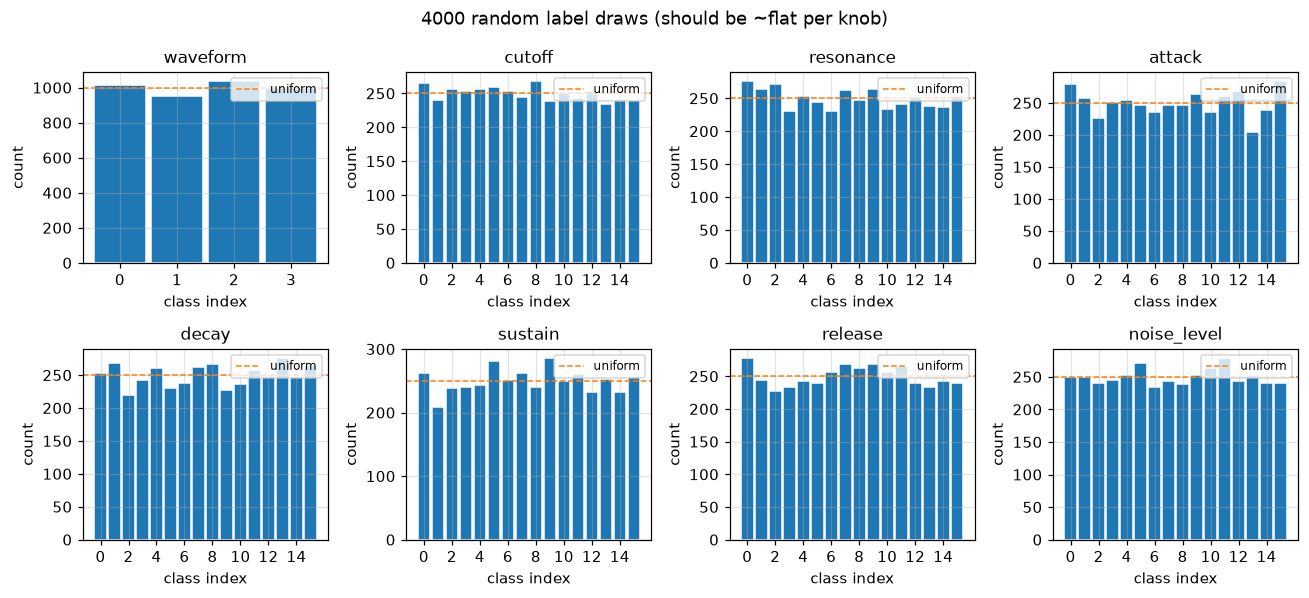

               0      1       2      3      4      5      6      7      8   \
waveform   1013.0  954.0  1037.0  996.0    NaN    NaN    NaN    NaN    NaN   
cutoff      265.0  240.0   257.0  253.0  257.0  259.0  254.0  245.0  268.0   
resonance   276.0  264.0   272.0  230.0  254.0  244.0  231.0  262.0  247.0   
attack      279.0  257.0   226.0  251.0  255.0  246.0  236.0  247.0  247.0   
decay       253.0  269.0   219.0  242.0  260.0  230.0  238.0  262.0  267.0   

              9      10     11     12     13     14     15  
waveform     NaN    NaN    NaN    NaN    NaN    NaN    NaN  
cutoff     239.0  250.0  243.0  253.0  235.0  242.0  240.0  
resonance  264.0  233.0  242.0  252.0  239.0  236.0  254.0  
attack     264.0  236.0  261.0  268.0  204.0  239.0  284.0  
decay      228.0  237.0  258.0  248.0  276.0  247.0  266.0  


In [36]:
rng_labels = np.random.default_rng(SEED)
label_rows = [random_labels(SPEC, rng_labels) for _ in range(N_LABEL_DRAWS)]
labels_df = pd.DataFrame(label_rows)
assert labels_df.shape == (N_LABEL_DRAWS, len(SPEC)), labels_df.shape

fig, axes = plt.subplots(2, 4, figsize=(12, 5.5))
for ax, param in zip(axes.ravel(), SPEC):
    name = str(param["name"])
    n = int(param["n_classes"])
    ax.hist(
        labels_df[name],
        bins=np.arange(n + 1) - 0.5,
        color="C0",
        edgecolor="white",
        rwidth=0.9,
    )
    ax.set_title(name)
    ax.set_xlabel("class index")
    ax.set_ylabel("count")
    ax.set_xticks(range(n) if n <= 4 else range(0, n, 2))
    expected = N_LABEL_DRAWS / n
    ax.axhline(expected, color="C1", ls="--", lw=1, label="uniform")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle(f"{N_LABEL_DRAWS} random label draws (should be ~flat per knob)")
fig.tight_layout()
plt.show()

# a uniform draw over 16 classes, 4000 rows: expected count ≈ 250, std ≈ 15
print(labels_df.apply(lambda s: s.value_counts().sort_index()).T.head())

In [37]:
n_space = 1
factors: list[str] = []
for p in SPEC:
    n = int(p["n_classes"])
    n_space *= n
    factors.append(str(n))
print("discrete space size: " + " × ".join(factors) + f" = {n_space:,}")
print(f"check: 4 × 16^7 = {4 * 16**7:,}")
assert n_space == 4 * 16**7

rng_example = np.random.default_rng(SEED)
example_labels = random_labels(SPEC, rng_example)
example_preset = labels_to_preset(SPEC, example_labels)

print("example labels :", example_labels)
print("example values :", {k: (v if isinstance(v, str) else float(v)) for k, v in example_preset.items()})
print("describe       :", describe_preset(example_preset))
display(
    pd.DataFrame(
        {
            "class": example_labels,
            "value": example_preset,
        }
    )
)

discrete space size: 4 × 16 × 16 × 16 × 16 × 16 × 16 × 16 = 1,073,741,824
check: 4 × 16^7 = 1,073,741,824
example labels : {'waveform': 3, 'cutoff': 15, 'resonance': 15, 'attack': 6, 'decay': 2, 'sustain': 14, 'release': 1, 'noise_level': 4}
example values : {'waveform': 'triangle', 'cutoff': 10000.0, 'resonance': 10.0, 'attack': 0.015848931924611138, 'decay': 0.01847849797422291, 'sustain': 0.9333333333333333, 'release': 0.013593563908785257, 'noise_level': 0.13333333333333333}
describe       : waveform=triangle, cutoff=10000.0 Hz, resonance=10 Q, attack=0.01585 s, decay=0.01848 s, sustain=0.933, release=0.01359 s, noise_level=0.133


,class,value
waveform,3,triangle
cutoff,15,10000.0
resonance,15,10.0
attack,6,0.015849
decay,2,0.018478
sustain,14,0.933333
release,1,0.013594
noise_level,4,0.133333


**Output of this step.** `SPEC` is a list of 8 knob dicts. A label vector is `dict[str, int]` with 8 entries (waveform in \(\{0,1,2,3\}\), others in \(\{0,\ldots,15\}\)). `labels_to_preset` decodes that to physical values (`str` for waveform, `float` for the rest). The discrete search space has **\(4 \times 16^{7} = 1{,}073{,}741{,}824\)** points. The class→value table has shape `(16, 7)`.

A class vector is only numbers until you hear it. Below is a **minimal** synth (oscillator → noise → low-pass → ADSR) that turns `example_preset` into one **C3** note (MIDI 48, \(f_0 \approx 130.8\) Hz). This is a preview; Section 3 will unpack each stage with plots.

In [ ]:
def midi_to_hz(m: float) -> float:
    """Convert a MIDI note number to frequency in Hz (A4 = 440)."""
    return float(440.0 * (2.0 ** ((float(m) - 69.0) / 12.0)))


def oscillator(waveform: str, f0: float, n: int) -> np.ndarray:
    """Naive vectorized sine, saw (2u−1), square (sign sin), or triangle (2|2u−1|−1)."""
    phase = 2.0 * np.pi * float(f0) * np.arange(n, dtype=np.float64) / SAMPLE_RATE
    u = np.mod(phase / (2.0 * np.pi), 1.0)
    if waveform == "sine":
        return np.sin(phase)
    if waveform == "saw":
        return 2.0 * u - 1.0
    if waveform == "square":
        return np.sign(np.sin(phase))
    if waveform == "triangle":
        return 2.0 * np.abs(2.0 * u - 1.0) - 1.0
    raise ValueError(f"unknown waveform: {waveform}")


def add_noise(x: np.ndarray, level: float, rng: np.random.Generator) -> np.ndarray:
    """Add white noise in [−1, 1] scaled by level."""
    noise = rng.uniform(-1.0, 1.0, size=np.asarray(x).shape)
    return np.asarray(x, dtype=np.float64) + float(level) * noise


def lowpass(x: np.ndarray, cutoff: float, q: float) -> np.ndarray:
    """RBJ biquad low-pass; cutoff is clamped below 0.45 × SAMPLE_RATE."""
    fc = min(float(cutoff), 0.45 * SAMPLE_RATE)
    w0 = 2.0 * np.pi * fc / SAMPLE_RATE
    alpha = np.sin(w0) / (2.0 * float(q))
    cosw = np.cos(w0)
    b0 = (1.0 - cosw) / 2.0
    b1 = 1.0 - cosw
    b2 = (1.0 - cosw) / 2.0
    a0 = 1.0 + alpha
    a1 = -2.0 * cosw
    a2 = 1.0 - alpha
    b = np.array([b0, b1, b2], dtype=np.float64) / a0
    a = np.array([1.0, a1 / a0, a2 / a0], dtype=np.float64)
    return np.asarray(signal.lfilter(b, a, x), dtype=np.float64)


def adsr(
    attack: float, decay: float, sustain: float, release: float, n: int
) -> np.ndarray:
    """Linear ADSR; release starts from the level at note-off, even if decay is unfinished."""
    t = np.arange(n, dtype=np.float64) / SAMPLE_RATE
    env = np.zeros(n, dtype=np.float64)
    on = t < NOTE_HOLD_S
    att = float(attack)
    dec = float(decay)
    sus = float(sustain)
    rel = float(release)

    if att > 0.0:
        in_att = on & (t < att)
        env[in_att] = t[in_att] / att
        after_att = on & (t >= att)
    else:
        after_att = on
        env[on] = 1.0

    if dec > 0.0:
        in_dec = after_att & (t < att + dec)
        u = (t[in_dec] - att) / dec
        env[in_dec] = 1.0 + u * (sus - 1.0)
        env[after_att & (t >= att + dec)] = sus
    else:
        env[after_att] = sus

    def level_on(tq: float) -> float:
        if att > 0.0 and tq < att:
            return tq / att
        if dec > 0.0 and tq < att + dec:
            return 1.0 + ((tq - att) / dec) * (sus - 1.0)
        if att <= 0.0 and tq < att:
            return 1.0
        return sus

    level_off = level_on(NOTE_HOLD_S)
    if rel > 0.0:
        in_rel = (t >= NOTE_HOLD_S) & (t < NOTE_HOLD_S + rel)
        u = (t[in_rel] - NOTE_HOLD_S) / rel
        env[in_rel] = level_off * (1.0 - u)
    return env


def render(
    preset: dict[str, float | str],
    midi_note: int = MIDI_NOTE,
    seed: int = SEED,
    return_stages: bool = False,
) -> np.ndarray | dict[str, object]:
    """Render one note: oscillator → noise → low-pass → ADSR → peak-normalize."""
    rng = np.random.default_rng(seed)
    n = N_SAMPLES
    f0 = midi_to_hz(midi_note)
    osc = oscillator(str(preset["waveform"]), f0, n)
    noisy = add_noise(osc, float(preset["noise_level"]), rng)
    filt = lowpass(noisy, float(preset["cutoff"]), float(preset["resonance"]))
    env = adsr(
        float(preset["attack"]),
        float(preset["decay"]),
        float(preset["sustain"]),
        float(preset["release"]),
        n,
    )
    voiced = filt * env
    rms = float(np.sqrt(np.mean(voiced * voiced))) if voiced.size else 0.0
    silent = rms < SILENCE_RMS_THRESHOLD
    peak = float(np.max(np.abs(voiced))) if voiced.size else 0.0
    if (not silent) and peak > 0.0:
        out = (voiced * (PEAK_TARGET / peak)).astype(np.float32)
    else:
        out = voiced.astype(np.float32)
    if return_stages:
        return {
            "osc": osc,
            "noisy": noisy,
            "filtered": filt,
            "env": env,
            "pre_norm": voiced,
            "out": out,
            "rms": rms,
            "silent": silent,
            "f0": f0,
        }
    return out


f0_c3 = midi_to_hz(MIDI_NOTE)
example_audio = render(example_preset, midi_note=MIDI_NOTE, seed=SEED)
assert example_audio.shape == (N_SAMPLES,), example_audio.shape
print(f"C3  MIDI {MIDI_NOTE}  f0={f0_c3:.2f} Hz")
print(describe_preset(example_preset))
print(f"audio shape={example_audio.shape}  dtype={example_audio.dtype}")

fig, ax = plt.subplots(figsize=(10, 3.2))
t = np.arange(N_SAMPLES) / SAMPLE_RATE
ax.plot(t, example_audio, lw=0.8, color="0.15")
ax.axvline(NOTE_HOLD_S, color="C1", ls="--", label="note-off")
ax.set_title("example preset — C3")
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

show_audio(example_audio, label="example preset on C3 (MIDI 48)")

**Output of this preview.** `example_audio` is a C3 (MIDI 48) render of `example_preset`, shape `(44100,)` float32, peak-normalized. The orange dashed line is note-off at 1 s. Section 3 will show oscillator, noise, filter, and envelope separately.